In [1]:
import nltk
from nltk.corpus import treebank
nltk.download('treebank')
import statistics
import matplotlib.pyplot as plt

# Get sentences, words, and tagged words from the corpus

sentences = treebank.sents()      # List of sentences (each sentence is a list of words)
words = treebank.words()          # List of all words in the corpus
tagged_words = treebank.tagged_words()  # List of tuples (word, POS tag)

[nltk_data] Downloading package treebank to
[nltk_data]     /Users/larsheijnen/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


In [2]:
# Total number of sentences
total_sentences = len(sentences)

# Total number of words
total_words = len(words)

# Sentence lengths
sentence_lengths = [len(s) for s in sentences]

# Variance of sentence lengths
variance_sentence_length = round(statistics.pvariance(sentence_lengths), 3)

# Standard deviation of sentence lengths
std_dev_sentence_length = round(statistics.stdev(sentence_lengths), 3)

# Total number of unique words
unique_words = set(words)
total_unique_words = len(unique_words)

# Average sentence length (words per sentence)
average_sentence_length = round(total_words / total_sentences if total_sentences else 0, 3)

# Extract unique POS tags from the tagged words
unique_pos_tags = {tag for (word, tag) in tagged_words}
num_unique_pos_tags = len(unique_pos_tags)

# Print the statistics
print("Total number of sentences:", total_sentences)
print("Total number of words:", total_words)
print("Total number of unique words:", total_unique_words)
print("Average sentence length:", average_sentence_length)
print("Variance of sentence lengths:", variance_sentence_length)
print("Standard deviation of sentence lengths:", std_dev_sentence_length)
print("Number of unique POS tags:", num_unique_pos_tags)
print("Unique POS tags:", unique_pos_tags)

Total number of sentences: 3914
Total number of words: 100676
Total number of unique words: 12408
Average sentence length: 25.722
Variance of sentence lengths: 165.557
Standard deviation of sentence lengths: 12.869
Number of unique POS tags: 46
Unique POS tags: {'NN', 'WP$', 'NNP', 'RBR', 'WRB', '-LRB-', ':', '``', 'JJ', 'VB', 'NNS', 'CD', '-NONE-', 'WDT', 'VBZ', 'RP', 'VBP', 'MD', 'PDT', '.', 'WP', '$', 'VBG', 'TO', '-RRB-', 'RBS', 'SYM', 'DT', 'JJS', 'UH', 'NNPS', 'CC', ',', 'POS', "''", 'FW', 'JJR', 'PRP$', 'LS', 'VBN', 'PRP', '#', 'RB', 'EX', 'VBD', 'IN'}


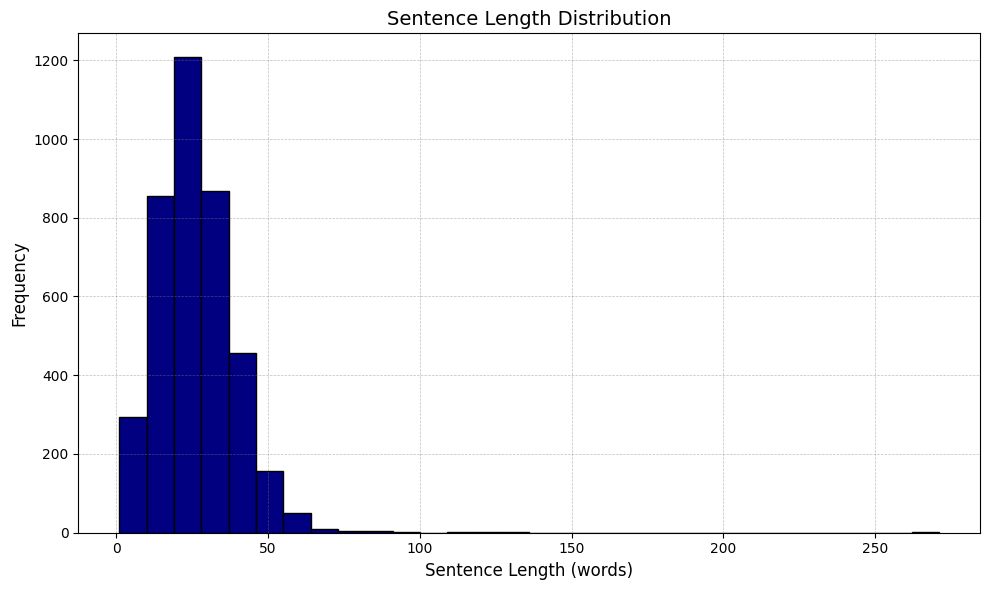

In [3]:
plt.figure(figsize=(10, 6), facecolor='white') 
plt.hist(sentence_lengths, bins=30, color='navy', edgecolor='black')

plt.title("Sentence Length Distribution", color='black', fontsize=14)
plt.xlabel("Sentence Length (words)", color='black', fontsize=12)
plt.ylabel("Frequency", color='black', fontsize=12)

plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')

# Optionally add a grid with lower contrast
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Show or save the plot
plt.tight_layout()
plt.show()


In [4]:
from collections import Counter

# Count the frequency of each word
word_frequencies = Counter(words)

# Get the top 10 most common words
top_10_frequent_words = word_frequencies.most_common(10)

print(f"{'Token':<15}{'Count':<10}")
print("-" * 25)
for word, count in top_10_frequent_words:
    print(f"{word:<15}{count:<10}")


Token          Count     
-------------------------
,              4885      
the            4045      
.              3828      
of             2319      
to             2164      
a              1878      
in             1572      
and            1511      
*-1            1123      
0              1099      


In [5]:
import re

# Define patterns to detect trace tokens and empty categories
TRACE_TOKEN_PATTERN = re.compile(r'^\*.*\*$|^\*$|^\*-?\d+$|^0$')

def is_valid_token(word, pos_tag=None):
    """
    Returns True if the token is a real word and not a syntactic trace or Treebank placeholder.
    """
    if pos_tag == '-NONE-':
        return False
    if TRACE_TOKEN_PATTERN.match(word):
        return False
    return True

# --- Create cleaned sentences as strings (ready for BERT) ---
cleaned_sentences = []
for sentence in treebank.tagged_sents():
    cleaned_tokens = [word for word, pos in sentence if is_valid_token(word, pos)]
    if cleaned_tokens:  # Skip if the result is empty
        cleaned_sentences.append(" ".join(cleaned_tokens))

# --- Optional: Token list version (if needed for manual token handling) ---
cleaned_token_lists = []
for sentence in treebank.tagged_sents():
    cleaned_tokens = [word for word, pos in sentence if is_valid_token(word, pos)]
    if cleaned_tokens:
        cleaned_token_lists.append(cleaned_tokens)

# --- Example Output ---
print("Original:", " ".join(word for word, _ in treebank.tagged_sents()[18]))
print("Cleaned :", cleaned_sentences[18])

Original: `` The morbidity rate is a striking finding among those of us who *T*-5 study asbestos-related diseases , '' said *T*-1 Dr. Talcott .
Cleaned : `` The morbidity rate is a striking finding among those of us who study asbestos-related diseases , '' said Dr. Talcott .


In [6]:
# Gather statistics on the cleaned data
cleaned_total_sentences = len(cleaned_sentences)
cleaned_all_tokens = [token for sentence_tokens in cleaned_token_lists for token in sentence_tokens]
cleaned_total_tokens = len(cleaned_all_tokens)
cleaned_unique_tokens = set(cleaned_all_tokens)
cleaned_total_unique_tokens = len(cleaned_unique_tokens)

# Sentence length statistics
cleaned_sentence_lengths = [len(sentence_tokens) for sentence_tokens in cleaned_token_lists]
if len(cleaned_sentence_lengths) > 1:
    cleaned_variance_sentence_length = round(statistics.pvariance(cleaned_sentence_lengths), 3)
    cleaned_std_dev_sentence_length = round(statistics.stdev(cleaned_sentence_lengths), 3)
else:
    cleaned_variance_sentence_length = 0
    cleaned_std_dev_sentence_length = 0

# Average sentence length
cleaned_average_sentence_length = round(cleaned_total_tokens / cleaned_total_sentences if cleaned_total_sentences else 0, 3)

# Extract cleaned POS tags
cleaned_tagged_tokens = []
for sentence in treebank.tagged_sents():
    cleaned_tagged_tokens.extend([(word, pos) for word, pos in sentence if is_valid_token(word, pos)])
cleaned_unique_pos_tags = {tag for (word, tag) in cleaned_tagged_tokens}
cleaned_num_unique_pos_tags = len(cleaned_unique_pos_tags)

# Print the statistics
print("\n--- Statistics for Cleaned Data ---")
print("Total number of sentences:", cleaned_total_sentences)
print("Total number of words:", cleaned_total_tokens)
print("Total number of unique words:", cleaned_total_unique_tokens)
print("Average sentence length:", cleaned_average_sentence_length)
print("Variance of sentence lengths:", cleaned_variance_sentence_length)
print("Standard deviation of sentence lengths:", cleaned_std_dev_sentence_length)
print("Number of unique POS tags:", cleaned_num_unique_pos_tags)
print("Unique POS tags:", cleaned_unique_pos_tags)

# Print comparison with original data
print("\n--- Comparison with Original Data ---")
print(f"Sentences removed: {total_sentences - cleaned_total_sentences}")
print(f"Words removed: {total_words - cleaned_total_tokens}")
print(f"Unique words removed: {total_unique_words - cleaned_total_unique_tokens}")
print(f"Change in average sentence length: {cleaned_average_sentence_length - average_sentence_length:.3f}")
print(f"Change in sentence length variance: {cleaned_variance_sentence_length - variance_sentence_length:.3f}")
print(f"POS tags removed: {num_unique_pos_tags - cleaned_num_unique_pos_tags}")

# Most frequent tokens in cleaned data
from collections import Counter
cleaned_word_frequencies = Counter(cleaned_all_tokens)
cleaned_top_10_frequent_words = cleaned_word_frequencies.most_common(10)

print("\n--- Most Frequent Tokens in Cleaned Data ---")
print(f"{'Token':<15}{'Count':<10}")
print("-" * 25)
for word, count in cleaned_top_10_frequent_words:
    print(f"{word:<15}{count:<10}")


--- Statistics for Cleaned Data ---
Total number of sentences: 3914
Total number of words: 94084
Total number of unique words: 11968
Average sentence length: 24.038
Variance of sentence lengths: 140.696
Standard deviation of sentence lengths: 11.863
Number of unique POS tags: 45
Unique POS tags: {'NN', 'WP$', 'NNP', 'RBR', 'WRB', '-LRB-', ':', '``', 'JJ', 'VB', 'NNS', 'CD', 'WDT', 'RP', 'VBZ', 'VBP', 'MD', 'PDT', '.', 'WP', '$', 'VBG', 'TO', '-RRB-', 'RBS', 'SYM', 'DT', 'JJS', 'UH', 'NNPS', 'CC', ',', 'POS', "''", 'FW', 'JJR', 'PRP$', 'LS', 'VBN', 'PRP', '#', 'RB', 'EX', 'VBD', 'IN'}

--- Comparison with Original Data ---
Sentences removed: 0
Words removed: 6592
Unique words removed: 440
Change in average sentence length: -1.684
Change in sentence length variance: -24.861
POS tags removed: 1

--- Most Frequent Tokens in Cleaned Data ---
Token          Count     
-------------------------
,              4885      
the            4045      
.              3828      
of             2319 

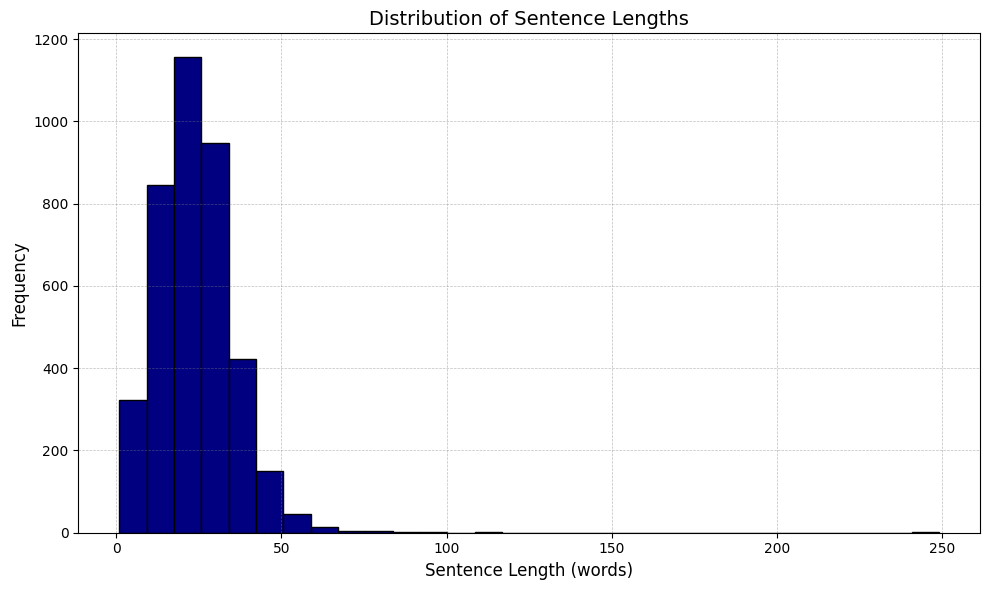

In [7]:
plt.figure(figsize=(10, 6), facecolor='white') 
plt.hist(cleaned_sentence_lengths, bins=30, color='navy', edgecolor='black')

plt.title("Distribution of Sentence Lengths", color='black', fontsize=14)
plt.xlabel("Sentence Length (words)", color='black', fontsize=12)
plt.ylabel("Frequency", color='black', fontsize=12)

plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')

# Optionally add a grid with lower contrast
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Show or save the plot
plt.tight_layout()
plt.show()


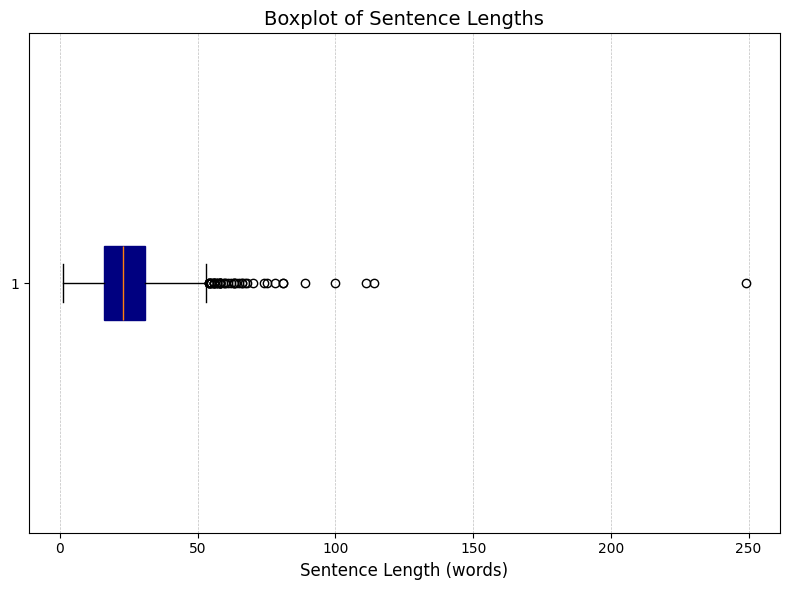

In [8]:
plt.figure(figsize=(8, 6), facecolor='white')
plt.boxplot(cleaned_sentence_lengths, vert=False, patch_artist=True, boxprops=dict(facecolor='navy', color='navy'))

plt.title("Boxplot of Sentence Lengths", fontsize=14, color='black')
plt.xlabel("Sentence Length (words)", fontsize=12, color='black')


plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5, axis='x')
plt.tight_layout()
plt.show()

In [9]:
import numpy as np 


sentence_lengths = [len(sentence.split()) for sentence in cleaned_sentences]

Q1 = np.percentile(sentence_lengths, 25)
Q3 = np.percentile(sentence_lengths, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_sentences = [(i, sentence, len(sentence.split())) 
                     for i, sentence in enumerate(cleaned_sentences) 
                     if len(sentence.split()) < lower_bound or len(sentence.split()) > upper_bound]


# Print outlier information
print(f"Number of outlier sentences: {len(outlier_sentences)}")
for idx, sentence, length in outlier_sentences[:5]:  # Display first 5 outliers
    print(f"Index: {idx}, Length: {length}, Sentence: {sentence}")

Number of outlier sentences: 46
Index: 118, Length: 54, Sentence: John Rowe , president and chief executive officer of New England Electric , said the company 's return on equity could suffer if it made a higher bid and its forecasts related to PS of New Hampshire -- such as growth in electricity demand and improved operating efficiencies -- did n't come true .
Index: 200, Length: 58, Sentence: Besides Messrs. Cray and Barnum , other senior management at the company includes Neil Davenport , 47 , president and chief executive officer ; Joseph M. Blanchard , 37 , vice president , engineering ; Malcolm A. Hammerton , 40 , vice president , software ; and Douglas R. Wheeland , 45 , vice president , hardware .
Index: 457, Length: 89, Sentence: But other than the fact that besuboru is played with a ball and a bat , it 's unrecognizable : Fans politely return foul balls to stadium ushers ; the strike zone expands depending on the size of the hitter ; ties are permitted -- even welcomed -- sin

In [11]:
filtered_cleaned_sentences = [
    sentence for sentence in cleaned_sentences
    if lower_bound <= len(sentence.split()) <= upper_bound
]

# Gather statistics on the filtered cleaned data
filtered_total_sentences = len(filtered_cleaned_sentences)
filtered_all_tokens = [token for sentence in filtered_cleaned_sentences for token in sentence.split()]
filtered_total_tokens = len(filtered_all_tokens)
filtered_unique_tokens = set(filtered_all_tokens)
filtered_total_unique_tokens = len(filtered_unique_tokens)

# Sentence length statistics
filtered_sentence_lengths = [len(sentence.split()) for sentence in filtered_cleaned_sentences]
if len(filtered_sentence_lengths) > 1:
    filtered_variance_sentence_length = round(statistics.pvariance(filtered_sentence_lengths), 3)
    filtered_std_dev_sentence_length = round(statistics.stdev(filtered_sentence_lengths), 3)
else:
    filtered_variance_sentence_length = 0
    filtered_std_dev_sentence_length = 0

# Average sentence length
filtered_average_sentence_length = round(filtered_total_tokens / filtered_total_sentences if filtered_total_sentences else 0, 3)

# Print the statistics
print("\n--- Statistics for Filtered Cleaned Data ---")
print("Total number of sentences:", filtered_total_sentences)
print("Total number of words:", filtered_total_tokens)
print("Total number of unique words:", filtered_total_unique_tokens)
print("Average sentence length:", filtered_average_sentence_length)
print("Variance of sentence lengths:", filtered_variance_sentence_length)
print("Standard deviation of sentence lengths:", filtered_std_dev_sentence_length)


--- Statistics for Filtered Cleaned Data ---
Total number of sentences: 3868
Total number of words: 90895
Total number of unique words: 11647
Average sentence length: 23.499
Variance of sentence lengths: 106.825
Standard deviation of sentence lengths: 10.337


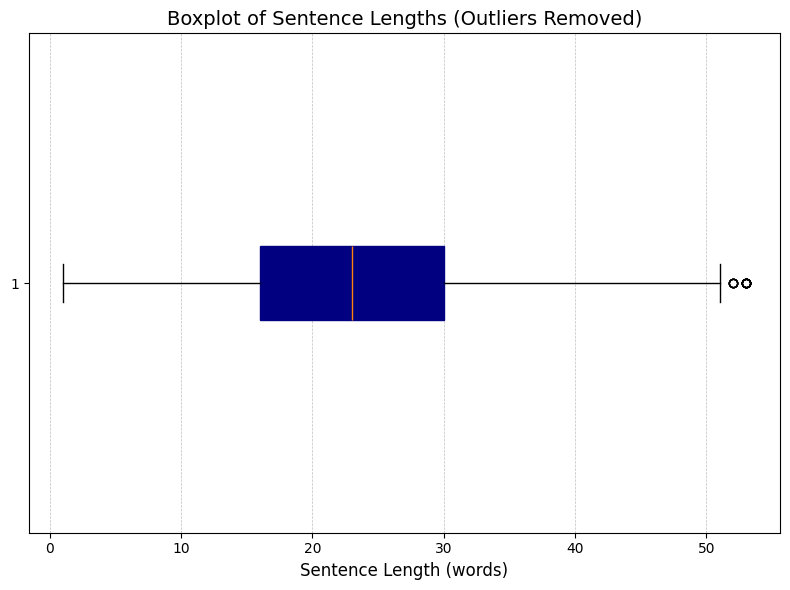

In [12]:
# Filter sentence lengths to remove outliers
filtered_sentence_lengths = [length for length in sentence_lengths if lower_bound <= length <= upper_bound]

# Plot the boxplot
plt.figure(figsize=(8, 6), facecolor='white')
plt.boxplot(filtered_sentence_lengths, vert=False, patch_artist=True, boxprops=dict(facecolor='navy', color='navy'))

plt.title("Boxplot of Sentence Lengths (Outliers Removed)", fontsize=14, color='black')
plt.xlabel("Sentence Length (words)", fontsize=12, color='black')

plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5, axis='x')
plt.tight_layout()
plt.show()

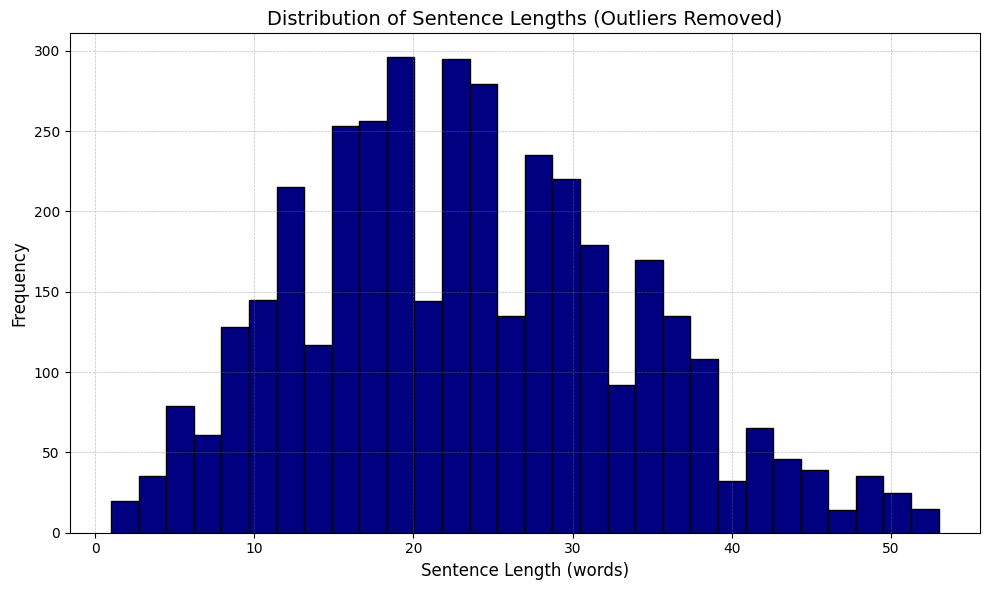

In [14]:
plt.figure(figsize=(10, 6), facecolor='white') 
plt.hist(filtered_sentence_lengths, bins=30, color='navy', edgecolor='black')

plt.title("Distribution of Sentence Lengths (Outliers Removed)", color='black', fontsize=14)
plt.xlabel("Sentence Length (words)", color='black', fontsize=12)
plt.ylabel("Frequency", color='black', fontsize=12)

plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')

# Optionally add a grid with lower contrast
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Show or save the plot
plt.tight_layout()
plt.show()

In [15]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

# Function to create BERT embeddings for each sentence
def get_bert_embeddings(texts):
    embeddings = []
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    model.eval()
    
    # Process in batches to avoid memory issues
    batch_size = 32
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            inputs = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt').to(device)
            outputs = model(**inputs)
            
            # Get [CLS] token embedding for each sentence (first token)
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(batch_embeddings)
    
    return np.array(embeddings)

# Generate BERT embeddings for preprocessed sentences without outliers
print("Generating BERT embeddings for filtered_cleaned_sentences (preprocessed, outliers removed)...")
X_sentence_features = get_bert_embeddings(filtered_cleaned_sentences)
print(f"Sentence BERT embeddings shape: {X_sentence_features.shape}")

Generating BERT embeddings for filtered_cleaned_sentences (preprocessed, outliers removed)...
Sentence BERT embeddings shape: (3868, 768)


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def train_linear_model(features, labels):
    """
    Train linear regression model to predict sentence length.

    Parameters:
      features (np.ndarray): Feature matrix of shape (num_samples, num_features).
      labels (list): Sentence length labels.

    Returns:
      model: Trained linear regression model.
      metrics: Dictionary containing evaluation metrics.
    """
    # Convert labels to numpy array
    labels = np.array(labels)

    # Splitting into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        features, labels, test_size=0.2, random_state=42
    )

    # Linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predictions on the test set
    predictions = model.predict(X_test)

    # Evaluation
    metrics = {
        "mean_squared_error": mean_squared_error(y_test, predictions),
        "mean_absolute_error": mean_absolute_error(y_test, predictions),
        "r2_score": r2_score(y_test, predictions),
    }

    return model, metrics, X_test, y_test

# Example usage with cleaned, filtered embeddings and sentence lengths
model, metrics, X_test, y_test = train_linear_model(X_sentence_features, filtered_cleaned_sentences)
print("Evaluation Metrics:", metrics)

ValueError: could not convert string to float: np.str_('Investors switched trading focus quickly as they did Tuesday , reflecting uncertainty about long-term commitments to any issue or sector , traders said .')

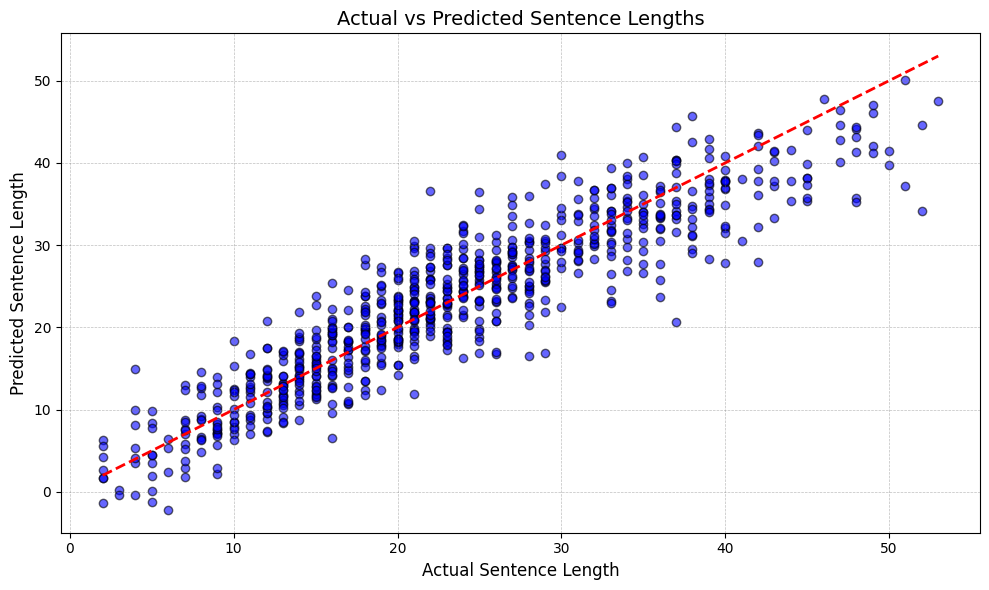

In [17]:
# Generate predictions for the test set
predictions = model.predict(X_test)

# Plot actual vs predicted sentence lengths
plt.figure(figsize=(10, 6), facecolor='white')
plt.scatter(y_test, predictions, alpha=0.6, color='blue', edgecolor='k')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2)

plt.title("Actual vs Predicted Sentence Lengths", fontsize=14, color='black')
plt.xlabel("Actual Sentence Length", fontsize=12, color='black')
plt.ylabel("Predicted Sentence Length", fontsize=12, color='black')

plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

In [14]:
import ipywidgets as widgets
from IPython.display import display

def display_prediction(index):
    if index < 0 or index >= len(X_test):
        print("Index out of range. Please select a valid index.")
        return

    # Get prediction from the linear regression model stored in 'model'
    prediction = model.predict([X_test[index]])[0]
    actual = y_test[index]

    try:
        original_sentence = filtered_cleaned_sentences[index]
        print(f"Original Sentence: {original_sentence}")
    except Exception:
        print("Original sentence not available.")
    
    print(f"Sentence Index: {index}")
    print(f"Predicted Sentence Length: {prediction:.2f}")
    print(f"Actual Sentence Length: {actual}")
    print(f"Absolute Error: {abs(prediction - actual):.2f}")

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(X_test) - 1,
    step=1,
    description="Sentence Index:",
    continuous_update=False
)

interactive_widget = widgets.interactive(display_prediction, index=slider)
display(interactive_widget)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Sentence Index:', max=777), Out…